In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp

import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [52]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools

import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')

from elements import *
from optimisers import *

import elements 
import importlib
importlib.reload(elements)


<module 'elements' from '/Users/matteogiacomelli/Documents/Technical_Student/simulation/Knobs in LSS4 SPS/elements.py'>

In [53]:
line = initialise_lineQ22()

Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4603 [00:00<?, ?it/s]

Non-channeled particle lost at element ap.up.mst21774_aper (index 1117) on turn 0
Adjusting ap.up.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21774_aper (index 1122) on turn 0
Adjusting ap.do.mst21774_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21779_aper (index 1125) on turn 0
Adjusting ap.up.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21779_aper (index 1130) on turn 0
Adjusting ap.do.mst21779_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.up.mst21794_aper (index 1133) on turn 0
Adjusting ap.up.mst21794_aper: increasing rectangular aperture.
The line already has an associated tracker
Non-channeled particle lost at element ap.do.mst21794_a

In [54]:
tw = line.twiss(method='4d')

tw_df = tw.to_pandas()
tw_df.set_index('name', inplace=True)
tw_df = tw_df.loc['mdha.21606':'drift_mdva.21932..1'] 
tw_df = tw_df.drop_duplicates(subset='s')


# Creating the knobs


In [55]:
import optimisers as op
import importlib
importlib.reload(op)

# Set the initial conditions
optLSS4 = horizontal_bumpLSS4(line)

optLSS4.log()
optLSS4.solve()

# Set the initial conditions
optLSS2 = horizontal_bumpLSS2(line, x_target = 0.0394, px_target = 1e-4)

optLSS2.log()
optLSS2.solve()

# bump_closed_orbite = ensure_bump_closed(line)

# bump_closed_orbite.log()

# bump_closed_orbite.step(10)
# bump_closed_orbite.target_status()
# bump_closed_orbite.vary_status()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values()
# knobs_after_closingOrbit = bump_closed_orbite.get_knob_values(iteration=0)

tw = line.twiss(continue_on_closed_orbit_error=True, method ="4d")


                                             
Optimize - start penalty: 0.5421                            
Matching: model call n. 19 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 2.757e-15                          
Matching: model call n. 21 penalty = 2.7566e-15              
Optimize - end penalty:  2.75657e-15                            
                                             
Optimize - start penalty: 0.3941                            
Matching: model call n. 22 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            
                                             
Optimize - start penalty: 1.799e-13                          
Matching: model call n. 24 penalty = 1.7989e-13              
Optimize - end penalty:  1.79888e-13                            


In [56]:
tab = line.get_table(attr=True)
line.vars.get_table()
tab.rows["mp.h\.2.*"].cols["k0l"]

bumpersLSS2 = list(line.vars.get_table().rows["kmp.h2.*[0-9]"].name)
bumpersLSS4 = list(line.vars.get_table().rows["kmp.h4.*[0-9]"].name)

In [57]:
for bumper in bumpersLSS2:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.env[bumper + "_init"] = line.vv[bumper]
    print(bumper, line.vv[bumper])

kmpsh21202 2.3933413057027092e-05
kmplh21431 0.0007837017618755222
kmpnh21732 -0.00012043265222573628
kmplh21995 0.0008602795605444746
kmplh22195 -0.0006035261662459959
kmpsh41402 -0.00036842332510076374
kmplh41658 -0.0006894284584424233
kmplh41994 -0.00063974812540521
kmpsh42198 -0.00017592643298445902


## Selecting the knobs

In [58]:
line.env["extr_bump_knob"] = 0.87 ## OPTIMAL FOR EXTRACTION
line.env["x_teca_knob"] = 1.02 ## OPRIMAL FOR EXTRACTION

In [59]:
for bumper in bumpersLSS2:
    line.vv[bumper] = bumper + "_init" + "*  extr_bump_knob"
    print(bumper, line.vv[bumper])

for bumper in bumpersLSS4:
    line.vv[bumper] = bumper + "_init" + "*  x_teca_knob"
    print(bumper, line.vv[bumper])

kmpsh21202 2.082206935961357e-05
kmplh21431 0.0006818205328317043
kmpnh21732 -0.00010477640743639056
kmplh21995 0.0007484432176736929
kmplh22195 -0.0005250677646340164
kmpsh41402 -0.00037579179160277903
kmplh41658 -0.0007032170276112718
kmplh41994 -0.0006525430879133142
kmpsh42198 -0.0001794449616441482


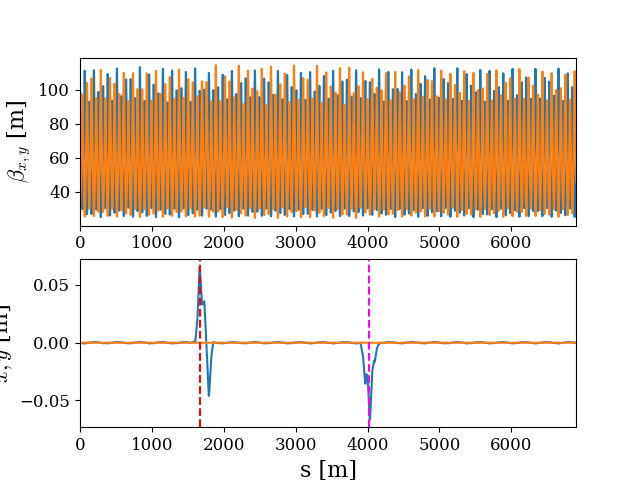

(0.0, 6900.0)

In [60]:
tw = line.twiss(continue_on_closed_orbit_error=True, method = '4d')

plt.figure()
ax1 = plt.subplot(2, 1, 1)
plt.plot(tw.s, tw.betx)
plt.plot(tw.s, tw.bety)
plt.ylabel(r"$\beta_{x,y}$ [m]")
plt.xlim(0,6900)
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
plt.plot(tw.s, tw.x)
plt.plot(tw.s, tw.y)
plt.axvline(tw["s", "zs.21633"], color="red", ls="--", label = "ZS entry")
plt.axvline(tw["s", "TECA.entry"], color="magenta", ls="--")
plt.ylabel(r"$x,y$ [m]")
plt.xlabel("s [m]")
plt.show()
plt.xlim(0,6900)

## Installing the septa and creating the beam

In [61]:
line.discard_tracker()
septa_names_with_apertures = install_septa(line, install_zs=False)
print(septa_names_with_apertures)

['tpst.21760_entry.sep', 'mst.21774.sep', 'mst.21779.sep', 'mst.21794.sep', 'mse.21832.sep', 'mse.21837.sep', 'mse.21852.sep', 'mse.21857.sep', 'mse.21872.sep']


In [62]:
n_part = 4000

x_norm   = np.random.normal(loc = 0, scale = 1, size=n_part)
px_norm =  np.random.normal(loc = 0, scale = 1, size=n_part)  # in between being channeled and not
#x_norm  = TECA.jaw * np.ones(n_part)
#px_norm = TECA.tilt * np.ones(n_part)
y_norm, py_norm = np.zeros(n_part), np.zeros(n_part)

zeta = 0.0
dpp = np.random.rand(n_part) * deltaP_P

line.build_tracker()

N_EX = 10e-7 # REDUCED NORMALISED EMITTANCE BY A FACTOR 10 AS MASSIMO GIOVANNOZZI SUGGESTED, IT IMPOVES THE EFFICIENY BY 1% !!!

particles = line.build_particles(
    method="4d",
    zeta=zeta,
    delta=dpp,
    x_norm=x_norm,
    px_norm=px_norm,
    y_norm=y_norm,
    py_norm=py_norm,
    nemitt_x=N_EX,
    nemitt_y=N_EY,
)

particles_init = particles.copy()
#tw_lss2 = tw.rows['TECA.entry':'_end_point']

tw_lss2 = tw.rows[:]


The line has collective elements.
In the twiss computation collective elements are replaced by drifts


### Reference momentum change

In [63]:
line.discard_tracker()

num_turns = 10000

# Define the momentum increment per turn (Δp₀c)
#delta_p0c =  2000e9 / 10 * 23e-6  # Example: 450 GeV over 10 s with 23 μs revolution time
delta_p0c = - 0.6e9 / num_turns  # THE SPS ENERGY CAN GO UP TO 400.6 GeV SO I ASSUME 0.6 GeV DIVIDED BY 100 TURNS

# Create the ReferenceEnergyIncrease element
energy_increase = xt.ReferenceEnergyIncrease(Delta_p0c=delta_p0c)

# Append the energy increase element to the end of the line
line.append_element(energy_increase, name='energy_increase')

<Line  at 4786573456>

### Inserting the monitors

In [64]:
#PLACING ONLY TWO MONITORS TO SAVE TIME
# Convert Twiss table to DataFrame and set 'name' as index
tw_lss2_df = tw_lss2.to_pandas()
tw_lss2_df.set_index('name', inplace=True)
tw_lss2_df = tw_lss2_df.drop_duplicates(subset='s')

# Remove tracker before inserting new elements
line.discard_tracker()

monitor_tun_number = 100

# INSERT THE FOLLOWING MONITORS IF YOU WANT TO GET THE PHASE SPACE PLOTS AT THE END OF THE SIMULATION

# Insert monitor only at 'TECA.exit'
monitor_teca = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TECA_monitor', element=monitor_teca, index='TECA.exit')
tw_lss2_df.loc['TECA.exit', 'monitors'] = monitor_teca

# Insert monitor only at 'tpst.21760_entry'
monitor_tpst = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TPST_monitor', element=monitor_tpst, index='tpst.21760_entry')
tw_lss2_df.loc['tpst.21760_entry', 'monitors'] = monitor_tpst

# Insert monitor only at tcsm.51932.
monitor_tcsm = xt.LastTurnsMonitor(n_last_turns=monitor_tun_number, num_particles=particles._capacity, every_n_turns=1)
line.insert_element(name='TCSM_monitor', element=monitor_tcsm, index='tcsm.51932.')
tw_lss2_df.loc['tcsm.51932.', 'monitors'] = monitor_tcsm

### Inserting TECA

In [65]:
line.discard_tracker()
#line.insert_element("extraction.crystal.TECS", TECS, at_s=line.get_table()['s', 'tecs.21602'] )
line.insert_element("extraction.crystal.TECA", TECA, at_s = line.get_table()['s', 'TECA.entry'] )

Slicing line:   0%|          | 0/4620 [00:00<?, ?it/s]

<Line  at 4786573456>

## MOving a lil bit the septum elements

In [66]:
# Move the blade_position of 'mst.21794.sep'
element_name = 'mst.21794.sep'
line[element_name].interaction_process.blade_position += 0.002  # 1 mm = 0.001 m
print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

New blade_position for mst.21794.sep: 0.0444 m


In [67]:
# element_name = 'mst.21774.sep' # should I move it?? ===> NO! It hsould stay where it is
# line[element_name].interaction_process.blade_position -= 0.001  # 1 mm = 0.001 m
# print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

In [68]:
# element_name = 'mst.21779.sep' # should i move it down or up?
# line[element_name].interaction_process.blade_position += 0.001  # 1 mm = 0.001 m
# print(f"New blade_position for {element_name}: {line[element_name].interaction_process.blade_position} m")

# Tracking

In [69]:
#line.discard_tracker()
#line.build_tracker(_context=xo.ContextCpu())
context = xo.ContextCpu(omp_num_threads='auto')

particles = particles_init.copy()
line.track(
    particles,
    num_turns=num_turns,
    turn_by_turn_monitor=True,
    # freeze_longitudinal=True,
    time=True
)
if np.any(particles.state < 1):
    lost_particles = np.where(particles.state < 1)[0]
    print(f"Particles lost during tracking: {len(lost_particles)}")
else:
    print("No particles lost during tracking")
record = line.time_last_track

Particles lost during tracking: 4000


# Printing the losses

In [70]:
import numpy as np

# Get indices of lost particles
lost_particles = np.where(particles.state < 1)[0]

if len(lost_particles) > 0:
    print(f"Number of lost particles: {len(lost_particles)}")
    print("\nParticle loss locations:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element
    loss_counts = {}
    for idx in lost_particles:
        lost_at = particles.at_element[idx]  # Index of element where the particle was lost
        lost_element_name = element_names[lost_at]
        loss_counts[lost_element_name] = loss_counts.get(lost_element_name, 0) + 1

    # Print where the particles were lost
    for element, count in loss_counts.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles were lost during tracking")

Number of lost particles: 4000

Particle loss locations:
3825 particles lost at element 'tt20.extraction'
131 particles lost at element 'tpst.21760_entry.sep'
37 particles lost at element 'extraction.crystal.TECA'
1 particles lost at element 'qe.11402_aper'
1 particles lost at element 'drift_mdh.43407..1'
3 particles lost at element 'qe.50202_aper'
1 particles lost at element 'qfa.21810_aper'
1 particles lost at element 'mdhw.11732_aper'


In [71]:
# Find indices of lost particles at 'tpst.21760_entry.sep'
lost_at_tpst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tpst.21760_entry.sep'
]

# if lost_at_tpst:
#     print("Particles lost at tpst.21760_entry.sep:")
#     lost_info = []
#     for idx in lost_at_tpst:
#         x_val = particles.x[idx]
#         px_val = particles.px[idx]
#         dpp_val = particles.delta[idx]
#         lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
#         print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
# else:
#     print("No particles lost at tpst.21760_entry.sep")

In [72]:
# Find indices of lost particles at 'mst.21794.sep'
lost_at_mst = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'mst.21794.sep'
]

if lost_at_mst:
    print("Particles lost at mst.21794.sep:")
    lost_info = []
    for idx in lost_at_mst:
        x_val = particles.x[idx]
        px_val = particles.px[idx]
        dpp_val = particles.delta[idx]
        lost_info.append({'idx': idx, 'x': x_val, 'px': px_val, 'dpp': dpp_val})
        print(f"Particle {idx}: x = {x_val:.6e}, px = {px_val:.6e}, dpp = {dpp_val:.6e}")
else:
    print("No particles lost at mst.21794.sep")

No particles lost at mst.21794.sep


#  Extraction Efficiency

In [73]:
# Calculate extraction efficiency: particles lost at 'tt20' / total number of particles

# Find indices of lost particles at 'tt20'
lost_at_tt20 = [
    idx for idx in np.where(particles.state < 1)[0]
    if line.element_names[particles.at_element[idx]] == 'tt20.extraction'
]

n_lost_tt20 = len(lost_at_tt20)
n_total = particles_init._capacity

if n_total > 0:
    efficiency = n_lost_tt20 / n_total
    print(f"Extraction efficiency at 'tt20': {efficiency:.4%} ({n_lost_tt20}/{n_total})")
else:
    print("No particles in the initial distribution.")

Extraction efficiency at 'tt20': 95.6250% (3825/4000)


# Counting a particle passes through the crystal

In [82]:
print(particles.state)

[   0   -1    0 ... -332 -332 -332]


#### Particles lost on the crystal


In [ ]:
lost_state_minus_332_indices = np.where(particles.state == -332)[0]   # LOST ON THE CRYSTAL
print("Indices of particles lost with state -332:", lost_state_minus_332_indices)

Indices of particles lost with state -332: [ 246  399  642  762  831  875  973 1044 1045 1137 1320 1590 1591 1592
 1593 1913 2248 2249 2250 2586 2587 2588 2589 2590 2591 2928 2929 3334
 3335 3336 3337 3338 3995 3996 3997 3998 3999]


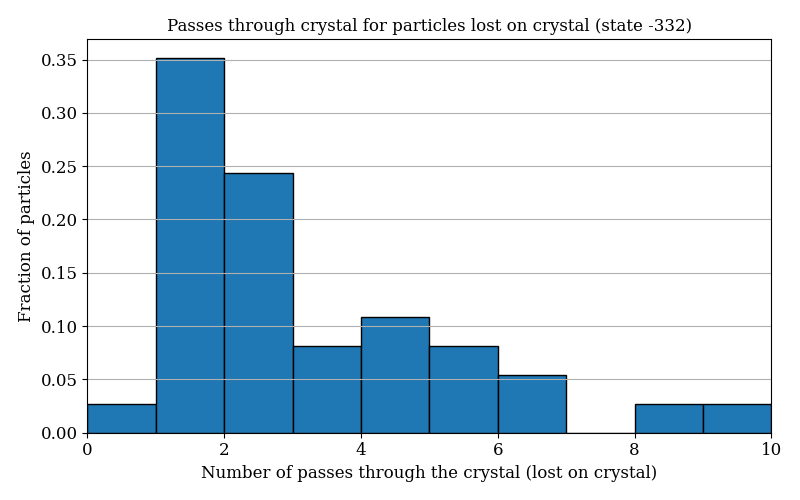

In [ ]:
# Get TECA jaw and width values
teca_jaw = TECA.jaw
teca_width = TECA.width

# Define the range for horizontal position
x_min = teca_jaw - teca_width
x_max = teca_jaw


# Only consider particles lost with state -332 (lost_state_minus_332_indices)
x_teca_lost = x_teca[lost_state_minus_332_indices]
counts_in_range_lost = np.sum((x_teca_lost >= x_min) & (x_teca_lost <= x_max), axis=1)

plt.figure(figsize=(8, 5))
plt.hist(counts_in_range_lost, bins=np.arange(counts_in_range_lost.max() + 2), edgecolor='black', density=True)
plt.xlim(0, counts_in_range_lost.max() + 1)
plt.xlabel('Number of passes through the crystal (lost on crystal)')
plt.ylabel('Fraction of particles')
plt.title("Passes through crystal for particles lost on crystal (state -332)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


### Particles lost on the septum

In [ ]:
lost_state_minus1_indices = np.where(particles.state == -1)[0]  # LOST ON THE SEPTUM, STATE = -1 IT MEANS LOST ON A global aperture limit set in the tracker. (BEAM INTERACTION)
print("Indices of particles lost with state -1:", lost_state_minus1_indices)

Indices of particles lost with state -1: [   1   27   37   88  116  150  169  196  228  233  285  311  502  506
  518  528  529  543  546  568  574  586  588  594  628  666  676  712
  713  714  760  761  789  829  830  873  874  924  972 1040 1041 1042
 1132 1133 1134 1135 1136 1316 1317 1318 1319 1579 1580 1581 1582 1583
 1584 1585 1586 1587 1588 1900 1901 1902 1903 1904 1905 1906 1907 1908
 1909 1910 1911 1912 2237 2238 2239 2240 2241 2242 2243 2244 2245 2246
 2247 2573 2574 2575 2576 2577 2578 2579 2580 2581 2582 2583 2584 2921
 2922 2923 2924 2925 2926 2927 3318 3319 3320 3321 3322 3323 3324 3325
 3326 3327 3328 3329 3330 3331 3981 3982 3983 3984 3985 3986 3987 3988
 3989 3990 3991 3992 3993 3994]


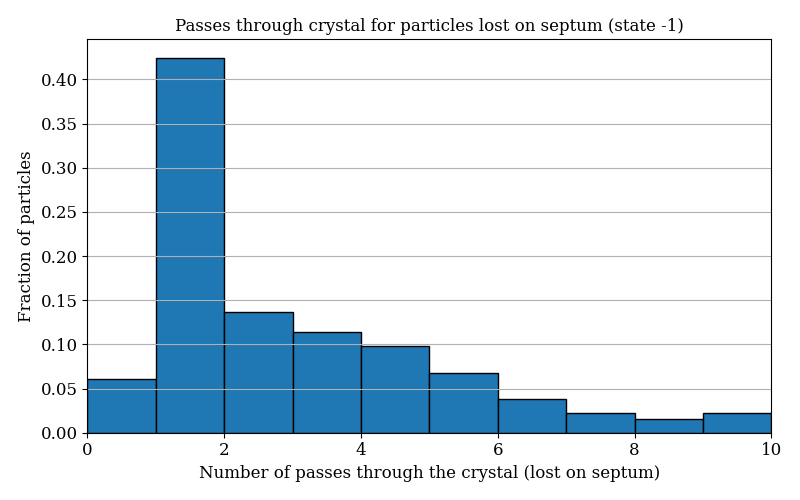

In [88]:
# Get TECA jaw and width values
teca_jaw = TECA.jaw
teca_width = TECA.width

# Define the range for horizontal position
x_min = teca_jaw - teca_width
x_max = teca_jaw


# Only consider particles lost with state - 1 (lost_state_minus1_indices)
x_teca_lost = x_teca[lost_state_minus1_indices]
counts_in_range_lost = np.sum((x_teca_lost >= x_min) & (x_teca_lost <= x_max), axis=1)

plt.figure(figsize=(8, 5))
plt.hist(counts_in_range_lost, bins=np.arange(counts_in_range_lost.max() + 2), edgecolor='black', density=True)
plt.xlim(0, counts_in_range_lost.max() + 1)
plt.xlabel('Number of passes through the crystal (lost on septum)')
plt.ylabel('Fraction of particles')
plt.title("Passes through crystal for particles lost on septum (state -1)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


#### Particles extracted

In [ ]:
lost_state_zero_indices = np.where(particles.state == 0)[0]    # LOST ON THE SEPTUM, STATE = 0 MEANS LOST ON A LIMIT RECT
print("Indices of particles lost with state 0:", lost_state_zero_indices)

Indices of particles lost with state 0: [   0    2    3 ... 3978 3979 3980]


/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_86417/3853567569.py:14: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(8, 5))


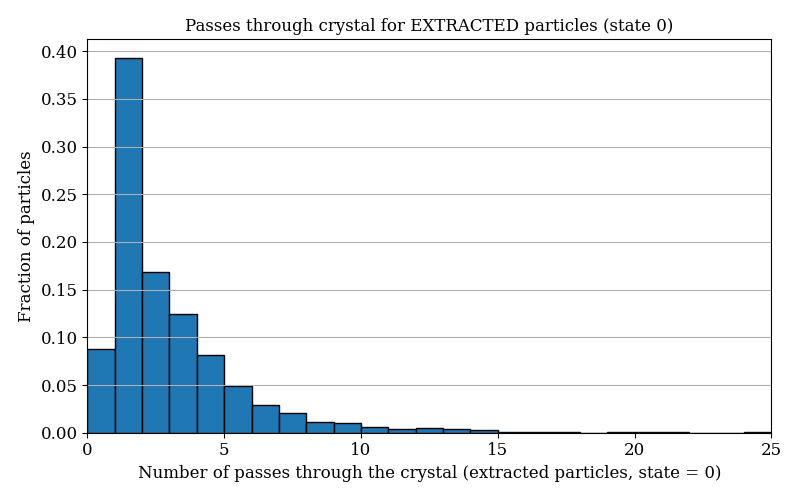

In [91]:
# Get TECA jaw and width values
teca_jaw = TECA.jaw
teca_width = TECA.width

# Define the range for horizontal position
x_min = teca_jaw - teca_width
x_max = teca_jaw


# Only consider particles lost with state - 1 (lost_state_zero_indices)
x_teca_lost = x_teca[lost_state_zero_indices]
counts_in_range_lost = np.sum((x_teca_lost >= x_min) & (x_teca_lost <= x_max), axis=1)

plt.figure(figsize=(8, 5))
plt.hist(counts_in_range_lost, bins=np.arange(counts_in_range_lost.max() + 2), edgecolor='black', density=True)
plt.xlim(0, counts_in_range_lost.max() + 1)
plt.xlabel('Number of passes through the crystal (extracted particles, state = 0)')
plt.ylabel('Fraction of particles')
plt.title("Passes through crystal for EXTRACTED particles (state 0)")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


### All particles combined

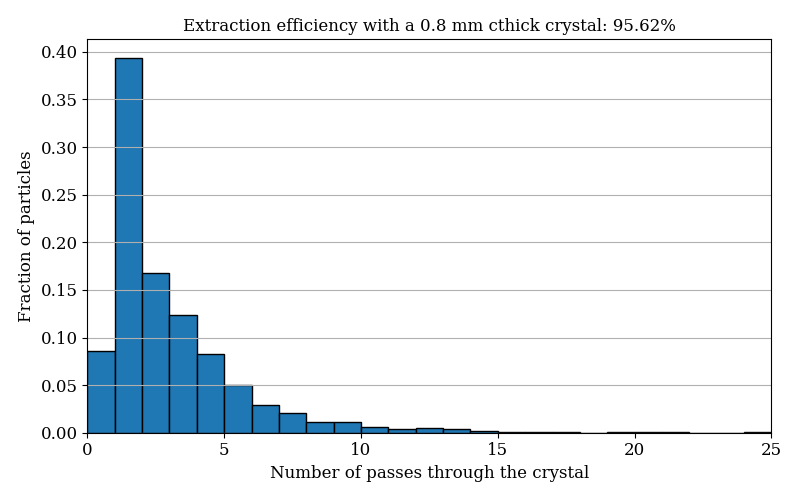

In [93]:
# Get TECA jaw and width values
teca_jaw = TECA.jaw
teca_width = TECA.width

# Define the range for horizontal position
x_min = teca_jaw - teca_width
x_max = teca_jaw

# Get the monitor at TECA.exit
#monitor_teca = row_TECA_exit['monitors']

# Count for each particle how many times x is in [x_min, x_max] over all monitored turns
x_teca = monitor_teca.x  # shape: (n_particles, n_turns)
in_range = (x_teca >= x_min) & (x_teca <= x_max)
counts_in_range = np.sum(in_range, axis=1)


# Plot a normalized histogram of the number of passes through the crystal for all particles
plt.figure(figsize=(8, 5))
plt.hist(counts_in_range, bins=np.arange(counts_in_range.max() + 2), edgecolor='black', density=True)
plt.xlim(0, counts_in_range.max() + 1)
plt.xlabel('Number of passes through the crystal')
plt.ylabel('Fraction of particles')
plt.title(f"Extraction efficiency with a 0.8 mm cthick crystal: {efficiency:.2%}")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# # Calculate extraction efficiency at 'tt20'
# efficiency_label = f" Count of particles"
# plt.legend([efficiency_label], loc='upper right')


### Checkings

In [75]:
zero_pass_indices = np.where(counts_in_range == 0)[0]
print("Indices of particles with zero passes through the crystal:", zero_pass_indices)

Indices of particles with zero passes through the crystal: [   8   26   29   34   55   93  116  120  124  126  146  235  267  300
  307  314  342  344  345  348  353  359  361  377  386  431  435  446
  447  453  454  458  464  479  496  500  502  510  533  551  554  559
  587  597  606  617  618  623  628  636  637  639  640  657  691  698
  704  709  730  735  736  737  740  741  745  747  756  804  805  827
  832  833  850  867  870  877  891  898  931  932  938  949  959  960
  963  983  995 1000 1003 1008 1025 1036 1042 1075 1079 1087 1088 1089
 1102 1108 1144 1145 1146 1162 1171 1178 1192 1201 1226 1234 1246 1273
 1274 1275 1277 1296 1307 1313 1322 1332 1337 1359 1363 1377 1389 1412
 1413 1430 1431 1454 1466 1470 1472 1474 1513 1518 1548 1561 1596 1617
 1634 1640 1644 1657 1685 1686 1689 1690 1696 1717 1723 1735 1737 1743
 1767 1786 1788 1796 1813 1820 1842 1856 1858 1878 1880 1882 1889 1898
 1912 1942 1945 1948 1976 1977 1982 1997 1998 2000 2006 2010 2013 2017
 2019 2035 2046 20

In [76]:
# Print where particles with zero passes through the crystal are lost

if len(zero_pass_indices) == 0:
    print(f"Number of particles with zero passes through the crystal: {len(zero_pass_indices)}")
    print("Loss locations for these particles:")

    # Get element names from the line
    element_names = line.element_names

    # Count losses per element for zero-pass particles
    loss_counts_zero_pass = {}
    for idx in zero_pass_indices:
        if particles.state[idx] < 1:
            lost_at = particles.at_element[idx]
            lost_element_name = element_names[lost_at]
            loss_counts_zero_pass[lost_element_name] = loss_counts_zero_pass.get(lost_element_name, 0) + 1

    for element, count in loss_counts_zero_pass.items():
        print(f"{count} particles lost at element '{element}'")
else:
    print("No particles with zero passes through the crystal.")

No particles with zero passes through the crystal.


# Phase space at TECA

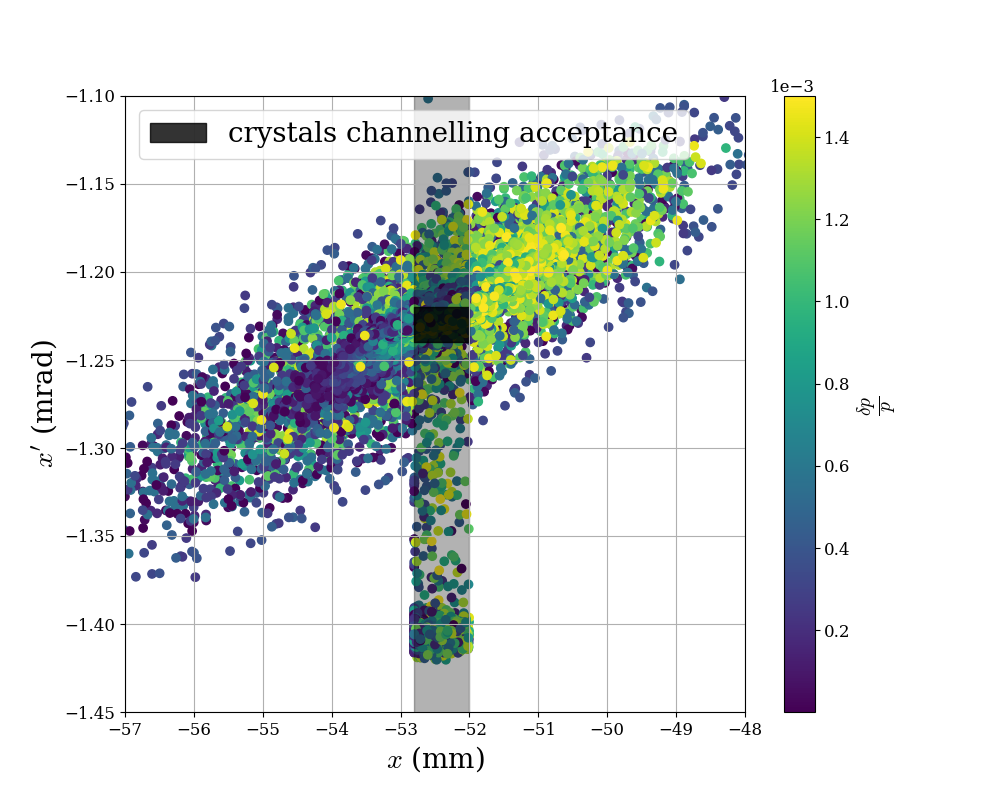

In [77]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TECA_exit['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.3)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20, loc = 'upper left')
ax.grid(True)

ax.set_xlim(-57, -48)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Time evolution at TECA location

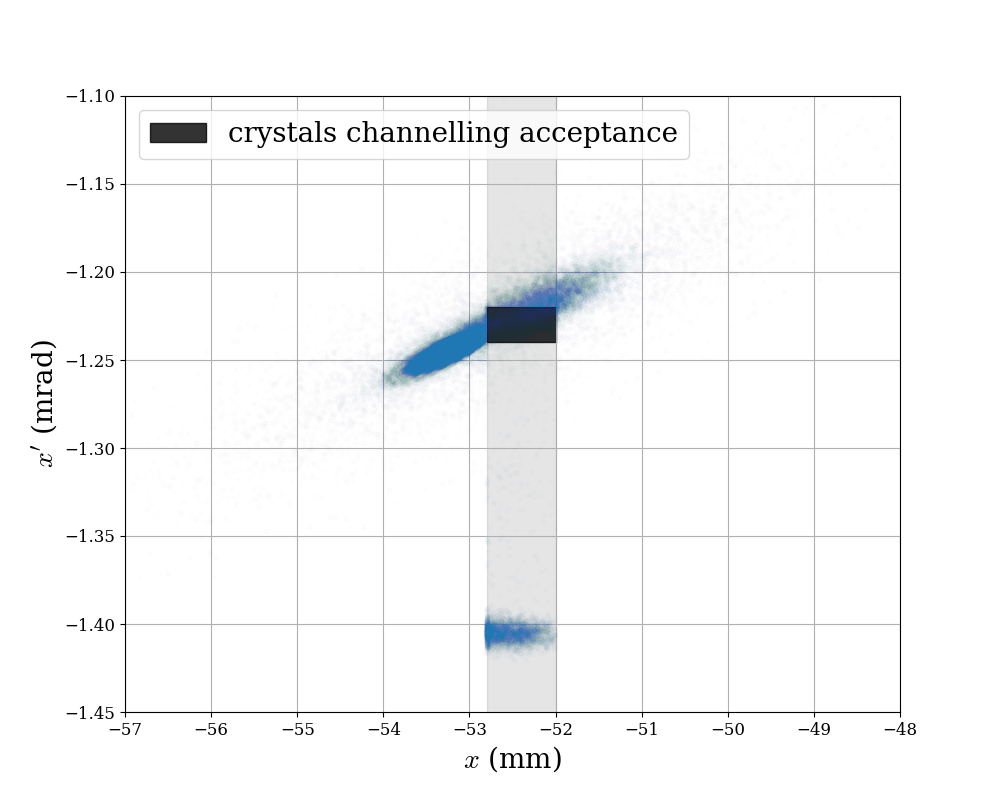

In [78]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TECA_entry = tw_lss2_df.loc['TECA.entry']
row_TECA_exit = tw_lss2_df.loc['TECA.exit']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TECA_exit['monitors'].x[:, turn] * 1e3,
        row_TECA_exit['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')

ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.8, label='crystals channelling acceptance')
ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 - TECA.width*1e3], -100, +100, color='k', alpha=0.1)

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(-57, -48)
ax.set_ylim(-1.45, -1.1)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Phase space at TPST

/var/folders/vc/njn3rgb96cq7_32jmcfzppkm0000gn/T/ipykernel_86417/3138404444.py:73: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('tpst_phase_space.png', bbox_inches='tight')
/Users/matteogiacomelli/miniforge3/envs/xsuite_env/lib/python3.11/site-packages/ipympl/backend_nbagg.py:335: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


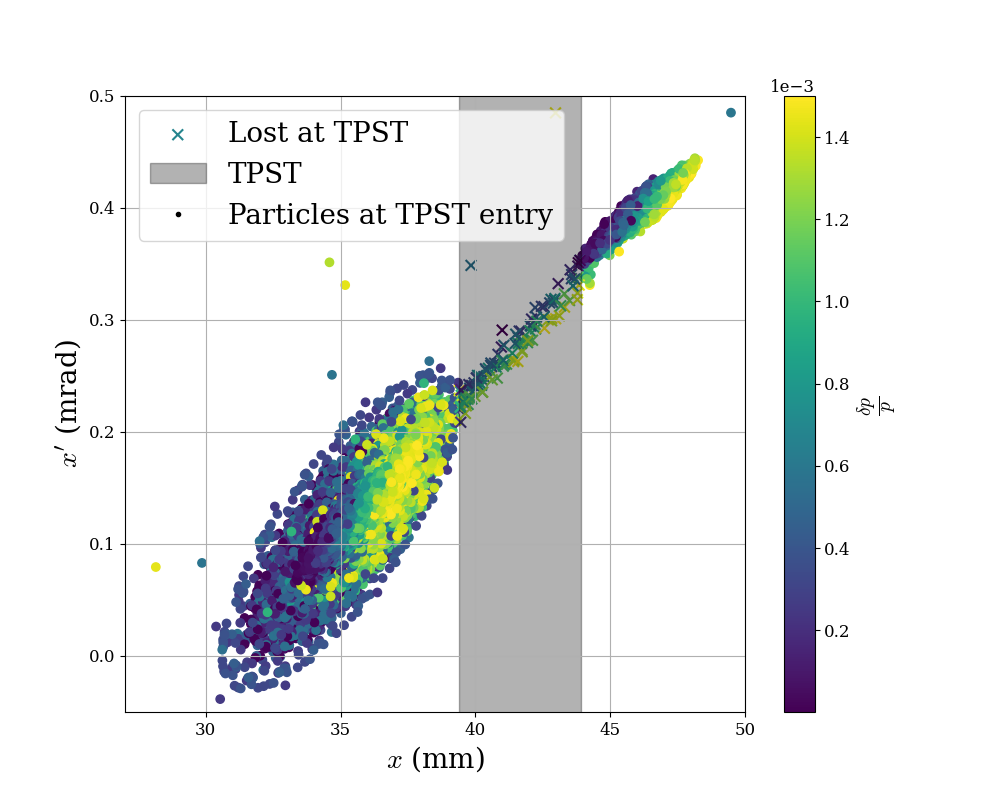

In [79]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

#ax.plot(row_TPST_entry['monitors'].x[:, :] * 1e3, row_TPST_entry['monitors'].px[:, :] * 1e3, 'k.', alpha=0.5)
for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TPST_entry['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
#plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# Plot the particles lost at tpst.21760_entry.sep
if lost_at_tpst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_tpst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_tpst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_tpst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

# Plot the particles lost at mst.21794.sep
if lost_at_mst:
    ax.scatter(
        [particles.x[idx] * 1e3 for idx in lost_at_mst],    # x in mm
        [particles.px[idx] * 1e3 for idx in lost_at_mst],   # px in mrad
        c=[particles.delta[idx] for idx in lost_at_mst],    # dpp for color
        cmap='viridis',
        marker='x',
        s=60,
        label='Lost at TPST'
    )

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.3, label='TPST')

ax.plot([], [], 'k.', label='Particles at TPST entry')

#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(27, 50)
ax.set_ylim(-0.05, 0.5)
ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tpst_phase_space.png', bbox_inches='tight')

# Time evolution at the TPST


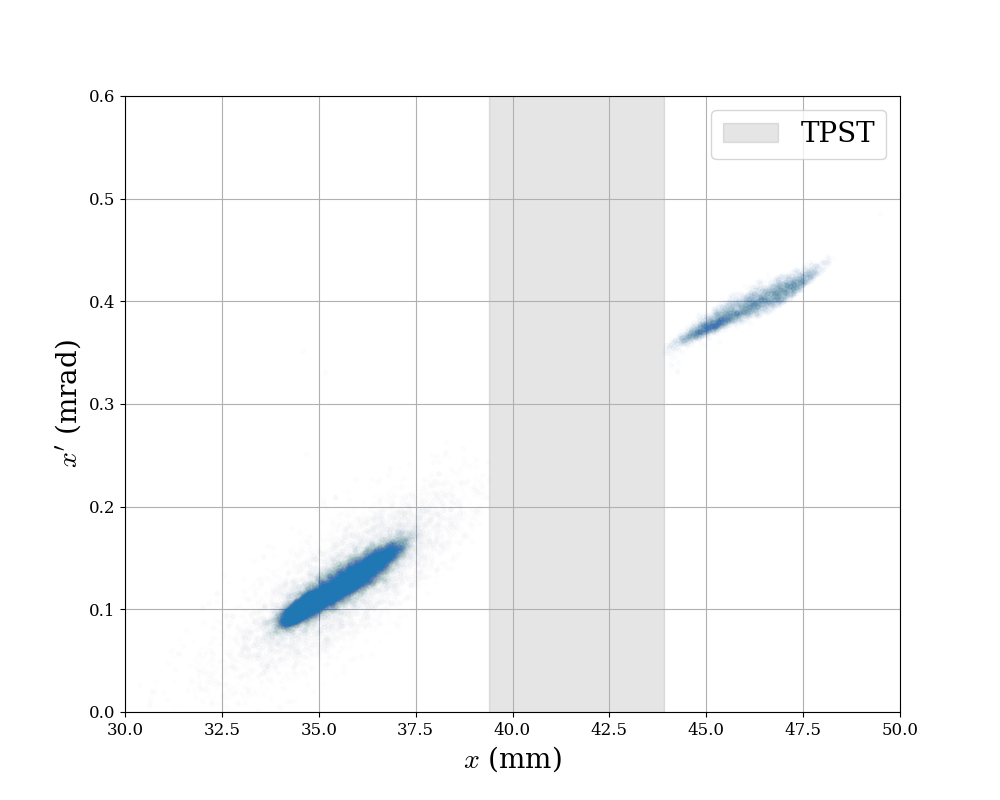

In [80]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TPST_entry = tw_lss2_df.loc['tpst.21760_entry']


fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    alpha_val = (turn + 1) / num_turns  # alpha increases from 0 to 1
    ax.plot(
        row_TPST_entry['monitors'].x[:, turn] * 1e3,
        row_TPST_entry['monitors'].px[:, turn] * 1e3,
        '.', 
        color='C0',
        alpha=alpha_val
    ) 

#ax.fill_between([TECA.jaw*1e3, TECA.jaw*1e3 + TECA.width*1e3], [TECA.tilt*1e3 - 10e-3]*2, [TECA.tilt*1e3 + 10e-3]*2, color='k', alpha=0.3, label='crystals channelling acceptance')
element_name = 'tpst.21760_entry.sep'
x = line[element_name].interaction_process.blade_position
thickness = line[element_name].interaction_process.thickness
ax.fill_between([x*1e3, x*1e3 + thickness*1e3],-1, 1, color='k', alpha=0.1, label='TPST')

#ax.plot([], [], 'k.', label='Particles at TECA entry')
#ax.plot([], [], 'b.', label='Particles after TECA')
#ax.set_title("Phase space at TECA over the last 100 turns", fontsize=20)
ax.legend(fontsize=20)
ax.grid(True)

ax.set_xlim(30, 50)
ax.set_ylim(0, 0.6)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('teca_phase_space.png', bbox_inches='tight')

# Phase space at the TCSM

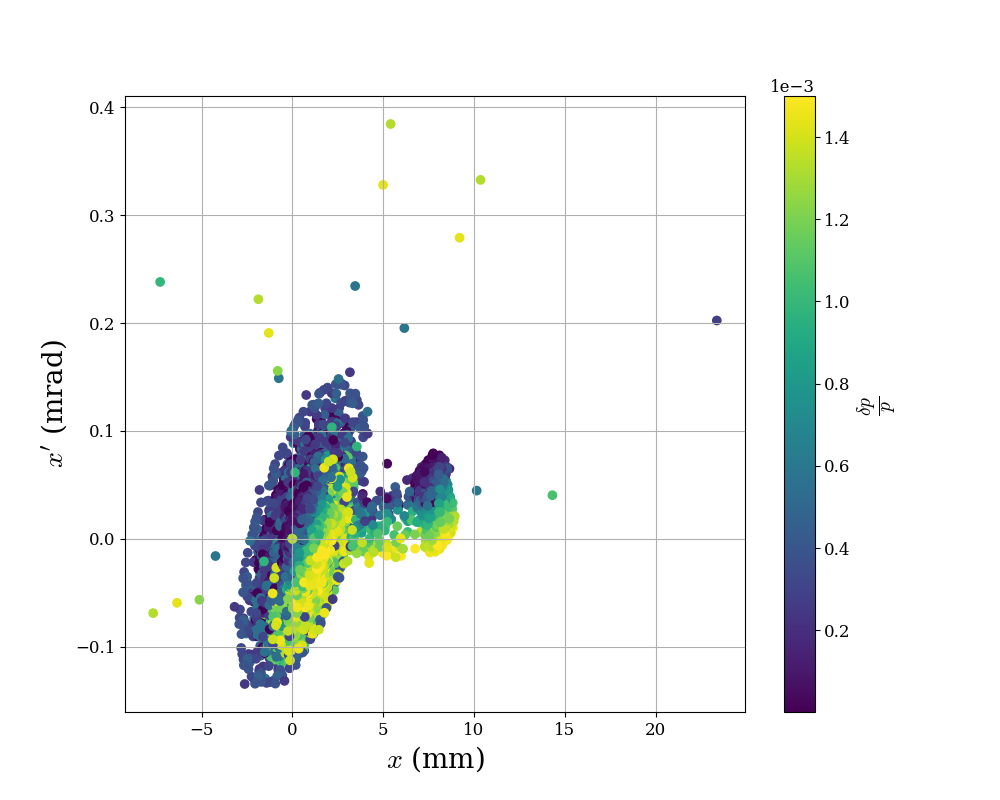

In [81]:
import matplotlib.pyplot as plt

# Set global plot style
plt.rcParams.update({
    'font.size': 12,          # Font size like a paper
    'font.family': 'serif',    # Use serif font (LaTeX style)
    'axes.labelsize': 12,      # Axis labels
    'axes.titlesize': 12,      # Title size
    'legend.fontsize': 12,     # Legend font size
    'xtick.labelsize': 12,     # X-axis tick labels
    'ytick.labelsize': 12,     # Y-axis tick labels
})

row_TCSM = tw_lss2_df.loc['tcsm.51932.']

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.yaxis.label.set_size(20)
ax.xaxis.label.set_size(20)

for turn in range(monitor_tun_number):
    sc = ax.scatter(
        row_TCSM['monitors'].x[:, turn] * 1e3,  # Use data for x at the current turn
        row_TCSM['monitors'].px[:, turn] * 1e3,  # Use data for px at the current turn
        c=particles_init._delta,  # Use dpp values from particles_init._delta
        cmap='viridis'
    )
cbar = plt.colorbar(sc, label=r"$\frac{\delta p}{p}$ ")
cbar.ax.yaxis.label.set_size(20)

# You can add acceptance/geometry overlays here if needed

#ax.legend(fontsize=20)
ax.grid(True)

# ax.set_xlim(-5, 15)
# ax.set_ylim(-0.15, 0.15)

ax.set_xlabel(r"$x$ (mm)")
ax.set_ylabel(r"$x'$ (mrad)")

plt.savefig('tcsm_phase_space.png', bbox_inches='tight')


